In [1]:
# Silence noisy library warnings (sklearn/xgboost version chatter, etc.)
# so the notebook output stays readable end to end.
import warnings
warnings.filterwarnings("ignore")

# 1. System and Problem Definition

**System Statement:** This notebook builds a diagnostic assistant: it looks at a patient's clinical and demographic data — glucose level, BMI, age, and a handful of other routine measurements — and predicts whether that patient has diabetes. The goal isn't to replace a doctor, but to give one a fast, low-cost first read on which patients are worth a closer look before a full clinical workup.

**Problem Definition (required questions):**

1. **What real-world problem does the system address?** Early, low-cost detection of diabetes, so timely medical intervention and lifestyle changes can reduce long-term health complications down the line.
2. **What information does the system receive?** A patient's age plus a set of clinical measurements: number of pregnancies, glucose level, blood pressure, skin thickness, insulin level, BMI, and a diabetes pedigree function score (a rough proxy for genetic risk).
3. **How is that information represented internally?** As a structured, 8-dimensional feature vector of real numbers. Zero readings that are physiologically impossible (like a Glucose or BMI of 0) are imputed with the training-set median, and the vector is standardized (mean 0, std 1) before being given to distance-based models.
4. **What does the model learn?** The statistical relationship — the decision boundary — between the input clinical features and the historic diagnosis (diabetic vs. non-diabetic).
5. **What decision or prediction does it produce?** A binary classification: 1 (Diabetic) or 0 (Non-Diabetic).
6. **Who or what uses the prediction?** Healthcare professionals, and, through the screening app, potentially patients themselves — as a preliminary signal, not a final word.

**Formal problem statement:** *Given the 8-dimensional clinical feature vector of a patient, predict whether that patient's diabetes outcome is positive (1) or negative (0) for a previously unseen observation.*

# 2. Intelligent System Diagram
The system follows the standard Input → Represent → Model → Predict pipeline:
```mermaid
flowchart LR
    A[Input:\nRaw Patient\nMedical Data] --> B[Represent:\nFeature Vector\n(Scaled Numerics)]
    B --> C[Model:\nTrained ML\nClassifier]
    C --> D[Predict:\nBinary Outcome\n(Diabetic / Non-Diabetic)]
```

# 3. Dataset Source
This project uses the "Diabetes Dataset" from Kaggle: [Kaggle - hasibur013/diabetes-dataset](https://www.kaggle.com/datasets/hasibur013/diabetes-dataset).

# 4. Dataset Description
- **Dataset Source:** Kaggle - Diabetes Dataset (https://www.kaggle.com/datasets/hasibur013/diabetes-dataset)
- **What real-world phenomenon is represented?** The physiological and demographic factors associated with diabetes onset in a population of female patients of Pima Indian heritage.
- **What is one observation?** A single patient's medical record at one point in time — a snapshot, not a history.
- **What are the features?** Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age.
- **What is the target?** `Outcome` (the diagnosis).
- **Is the target numerical or categorical?** Categorical (binary).
- **Is this regression or classification?** Classification.
- **How many observations are available?** 768.
- **How many features are available?** 8.
- **Which features are numerical?** All 8 — some continuous, some discrete integers.
- **Which features are categorical?** None of the input features; only the target `Outcome` is categorical.

# 5. Data Representation
Every patient is represented as an 8-dimensional numerical feature vector:

| Feature | Type | Representation | Meaning |
| --- | --- | --- | --- |
| Pregnancies | Numerical | Integer | Number of times pregnant |
| Glucose | Numerical | Real value | Plasma glucose concentration |
| BloodPressure | Numerical | Real value | Diastolic blood pressure (mm Hg) |
| SkinThickness | Numerical | Real value | Triceps skin fold thickness (mm) |
| Insulin | Numerical | Real value | 2-Hour serum insulin (mu U/ml) |
| BMI | Numerical | Real value | Body mass index |
| DiabetesPedigreeFunction | Numerical | Real value | Diabetes pedigree function |
| Age | Numerical | Integer | Age in years |

No categorical encoding is needed since every raw feature is already numerical. What the pipeline does instead is clean and rescale: zero values in Glucose, BP, SkinThickness, Insulin, and BMI are physiologically impossible, so they're treated as missing and imputed with the median — computed strictly from the training split, then reused on the test split, so no test information ever leaks into preprocessing. A feature therefore passes through three forms on its way to a model: **raw feature** (as read from the CSV, possibly an invalid 0) → **imputed feature** (0 replaced by the train median) → **model input** (the imputed feature standardized by `StandardScaler` for distance-based models; tree models consume the imputed-but-unscaled feature directly).

# 6. Feature and Target Analysis
Every input is numerical and the target is binary, so no encoding is required. What does need attention is scale: `DiabetesPedigreeFunction` sits under 1, while `Insulin` can climb past 100. Left as-is, that gap would let Insulin dominate any distance-based calculation, so the features are standardized (mean 0, std 1) before reaching distance-based algorithms like SVM and KNN.

# 7. Exploratory Data Analysis
Before training anything, it's worth looking at the data directly — how the features relate to each other, and how they differ between diabetic and non-diabetic patients.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Visual theme matching the deployed application (indigo = Diabetic, cyan = Non-Diabetic)
sns.set_theme(style='whitegrid', rc={'axes.edgecolor': '#e2e8f0', 'grid.color': '#eef2f7'})
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold'})

BRAND_DIABETIC = '#6366f1'      # indigo
BRAND_NON_DIABETIC = '#06b6d4'  # cyan
OUTCOME_PALETTE = {0: BRAND_NON_DIABETIC, 1: BRAND_DIABETIC}
BRAND_CMAP = LinearSegmentedColormap.from_list('brand_diverging', [BRAND_NON_DIABETIC, '#f8fafc', BRAND_DIABETIC])

# Load the dataset
df = pd.read_csv("diabetes_dataset.csv")

# Display the first few rows and the data types
display(df.head())
display(df.info())


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

# 1. Correlation Heatmap
A color-coded matrix of the Pearson correlation coefficient between every pair of numerical features, from -1 (perfect negative correlation) through 0 (no linear relationship) to +1 (perfect positive correlation). It's a quick way to spot which features move together and which ones look most predictive of `Outcome` — dark red/blue squares flag strong relationships worth a closer look, whether that's useful signal or multicollinearity to be aware of.

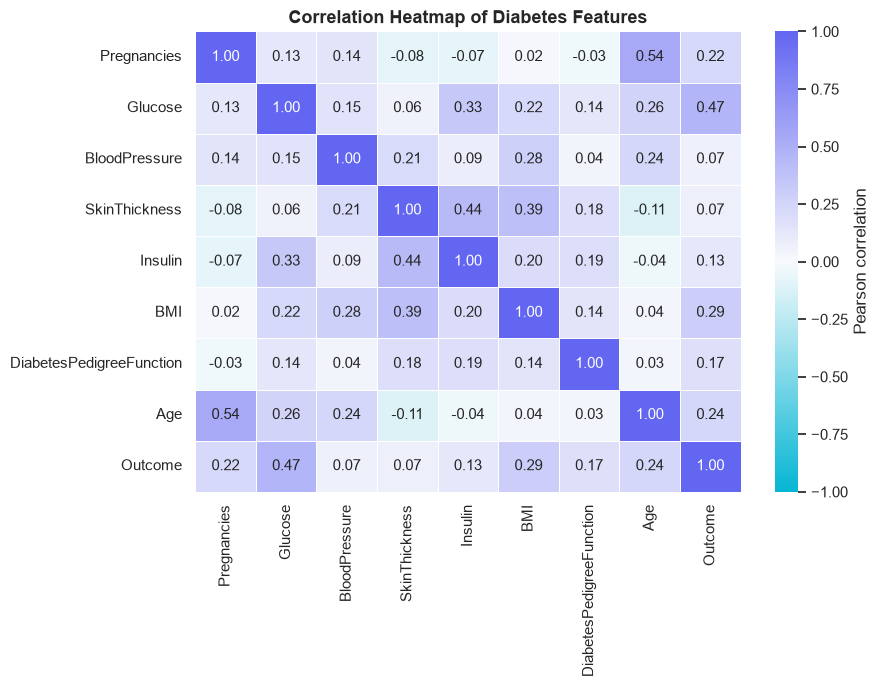

In [3]:
# 1. Correlation Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, cmap=BRAND_CMAP, fmt=".2f", vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation Heatmap of Diabetes Features')
plt.tight_layout()
plt.show()


# 2. Boxplots (Glucose, BMI, Age vs Outcome)
Boxplots split each feature's distribution by outcome class: the box marks the interquartile range, the line inside is the median, and the whiskers/diamonds show the typical range and outliers. They make it easy to compare the two groups' central tendency and spread at a glance — and here they show that median glucose and median BMI both sit noticeably higher among diabetic patients.

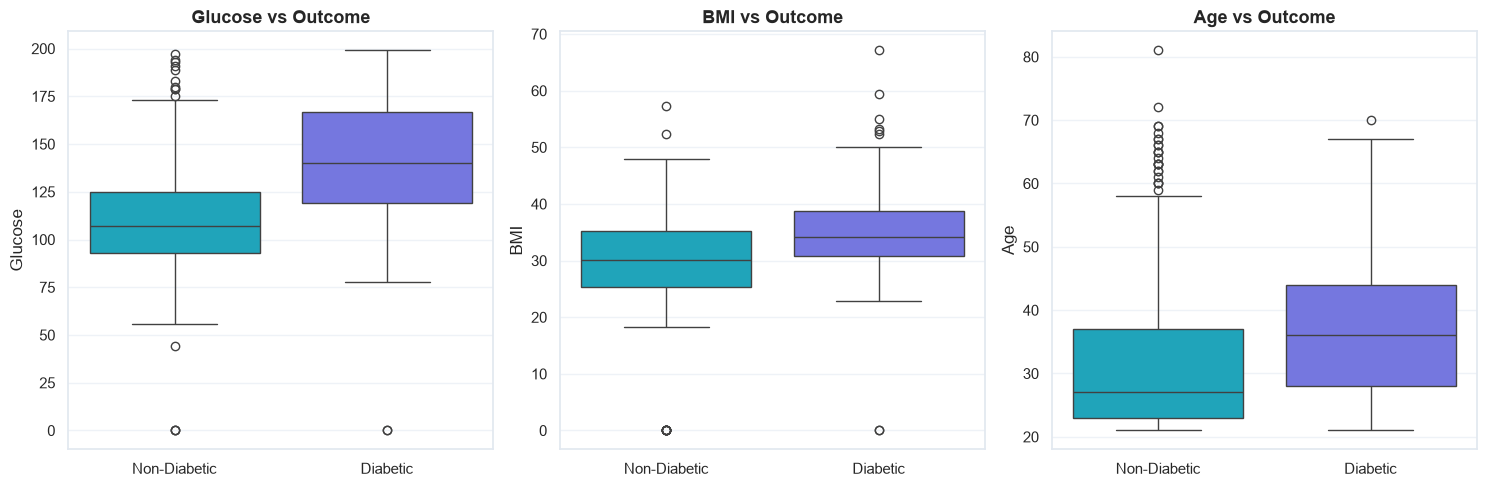

In [4]:
# 3. Boxplots for distributions by outcome
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feature in zip(axes, ['Glucose', 'BMI', 'Age']):
    sns.boxplot(x='Outcome', y=feature, data=df, hue='Outcome', palette=OUTCOME_PALETTE, legend=False, ax=ax)
    ax.set_title(f'{feature} vs Outcome')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])
    ax.set_xlabel('')

plt.tight_layout()
plt.show()


# 3. Target Variable Distribution (Countplot)
A simple bar chart of how many patients fall into each `Outcome` class. It tells us right away whether the dataset is balanced or not — here there are roughly twice as many non-diabetic patients as diabetic ones, which is exactly the kind of imbalance that makes accuracy alone a misleading metric and motivates the baseline comparison later on.

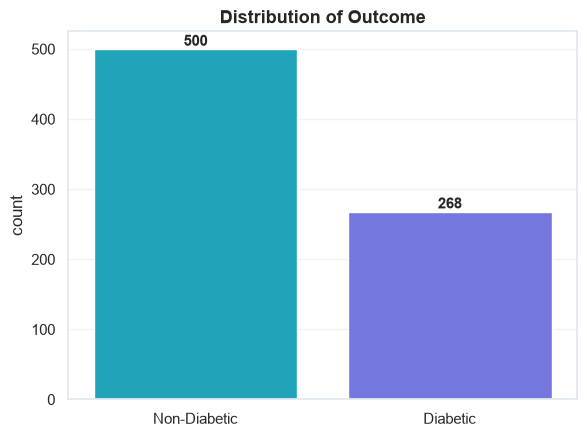

In [5]:
# 4. Target Variable Distribution
plt.figure(figsize=(6, 4.5))
ax = sns.countplot(x='Outcome', data=df, hue='Outcome', palette=OUTCOME_PALETTE, legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])
ax.set_xlabel('')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.title('Distribution of Outcome')
plt.tight_layout()
plt.show()


# 4. Joint Distribution of Glucose and BMI
The center panel is a scatter of Glucose against BMI, colored by outcome, with KDE curves along the top and right margins showing each feature's distribution per class. It's a concentrated view of the dataset's two strongest predictors — diabetic patients cluster toward the upper-right (high glucose, high BMI), and the margin curves make it easy to see exactly where the two classes' distributions start to diverge.

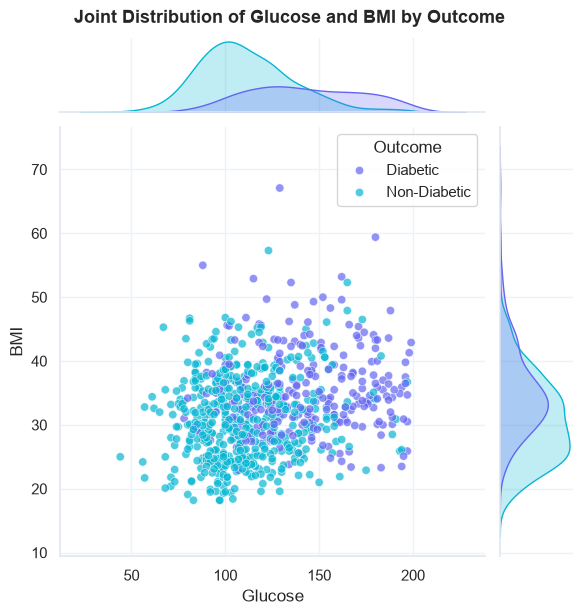

In [6]:
# 7. Joint Distribution of Glucose and BMI
# Filter out 0 values for BMI and Glucose to ensure the plot represents realistic medical data
df_clean = df[(df['BMI'] > 0) & (df['Glucose'] > 0)].copy()
df_clean['Outcome_Label'] = df_clean['Outcome'].map({0: 'Non-Diabetic', 1: 'Diabetic'})

g = sns.jointplot(x='Glucose', y='BMI', data=df_clean, hue='Outcome_Label',
                   palette={'Non-Diabetic': BRAND_NON_DIABETIC, 'Diabetic': BRAND_DIABETIC},
                   alpha=0.7, height=6)
g.ax_joint.legend(title='Outcome')
g.fig.suptitle('Joint Distribution of Glucose and BMI by Outcome', y=1.02, fontweight='bold')
plt.show()


# 8. Train/Test Split
The data is split 80% training / 20% testing (`stratify=y` keeps the diabetic/non-diabetic ratio balanced in both splits) **before** any imputation or scaling statistic is computed. The median imputer and the `StandardScaler` are then `fit()` on the training split only and `transform()`-ed onto both splits, so the test set never influences preprocessing — it's held back for evaluation only. This ordering matters: reusing the test set any earlier would let information about the evaluation data quietly bias every model's training.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# 1. Load Data
df = pd.read_csv("diabetes_dataset.csv")

# 2. Split BEFORE any imputation/scaling, so no test-set statistic
#    ever leaks into preprocessing decisions.
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_test = X_train.copy(), X_test.copy()

# 3. Treat physiologically-impossible zeros as missing, then impute
#    using statistics learned from the TRAINING split only.
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X_train[cols_to_impute] = X_train[cols_to_impute].replace(0, np.nan)
X_test[cols_to_impute] = X_test[cols_to_impute].replace(0, np.nan)

imputer = SimpleImputer(strategy='median')
X_train[cols_to_impute] = imputer.fit_transform(X_train[cols_to_impute])
X_test[cols_to_impute] = imputer.transform(X_test[cols_to_impute])
joblib.dump(imputer, 'imputer.pkl')

# 4. Feature Scaling (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, 'scaler.pkl')

# 5. Shared bookkeeping + rich-metrics helper for every model trained below
model_metrics = []
model_filenames = {}
model_needs_scaling = {}


def evaluate_model(name, model, X_te, y_te, filename, needs_scaling):
    """Score a fitted model with Accuracy/Precision/Recall/F1, log it for the
    Experiment 1 comparison table, save it to disk, and plot its confusion matrix."""
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)

    model_metrics.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    model_filenames[name] = filename
    model_needs_scaling[name] = needs_scaling
    joblib.dump(model, filename)

    print(f"Accuracy: {acc*100:.2f}% | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
    print(classification_report(y_te, y_pred, target_names=['Non-Diabetic', 'Diabetic']))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    return y_pred


# 9. Baseline
Before training anything real, it's worth establishing a floor: a `DummyClassifier` that always predicts the majority class (Non-Diabetic). If a trained model can't clearly beat this trivial strategy, it isn't actually learning anything useful from the features — that's the whole point of having a baseline. It's scored with the exact same rich-metrics helper as every other model, so it sits in the Experiment 1 comparison table on equal footing.

Accuracy: 64.94% | Precision: 0.000 | Recall: 0.000 | F1: 0.000
              precision    recall  f1-score   support

Non-Diabetic       0.65      1.00      0.79       100
    Diabetic       0.00      0.00      0.00        54

    accuracy                           0.65       154
   macro avg       0.32      0.50      0.39       154
weighted avg       0.42      0.65      0.51       154



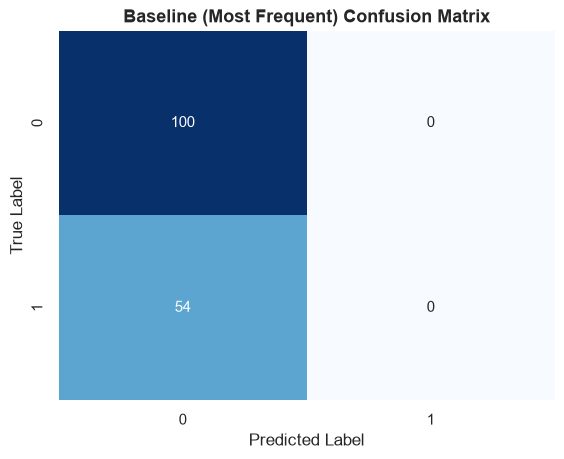

In [8]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = evaluate_model('Baseline (Most Frequent)', dummy, X_test, y_test, 'baseline.pkl', needs_scaling=False)

# 10. Model 1: Logistic Regression
A linear baseline model — `GridSearchCV` tunes the regularization strength `C` over 5 folds, then the best estimator is scored on the held-out test set.

Best Hyperparameters: {'C': 1}
Accuracy: 70.78% | Precision: 0.600 | Recall: 0.500 | F1: 0.545
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



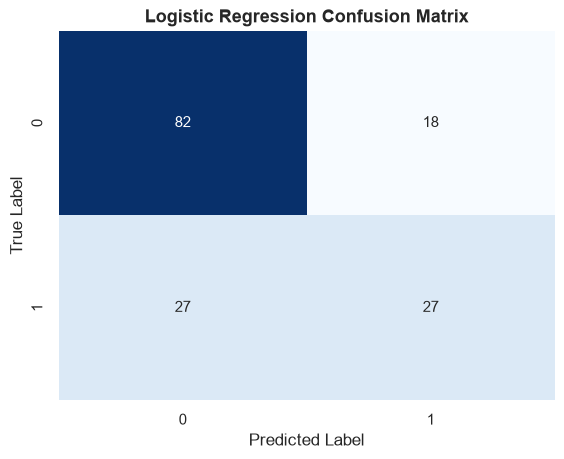

In [9]:
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_
print(f"Best Hyperparameters: {grid_lr.best_params_}")

y_pred_lr = evaluate_model('Logistic Regression', best_lr, X_test_scaled, y_test, 'logistic_regression.pkl', needs_scaling=True)


# 11. Model 2: SVM (Linear)
Searches for the maximum-margin hyperplane; `C` is tuned via `GridSearchCV` to control how strictly the margin is enforced.

Best Hyperparameters: {'C': 0.1}
Accuracy: 70.78% | Precision: 0.605 | Recall: 0.481 | F1: 0.536
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.83      0.79       100
    Diabetic       0.60      0.48      0.54        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.66       154
weighted avg       0.70      0.71      0.70       154



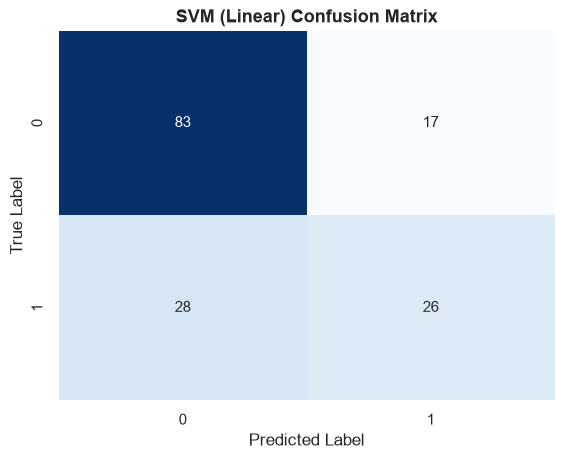

In [10]:
param_grid_svml = {'C': [0.01, 0.1, 1, 10]}
grid_svml = GridSearchCV(SVC(kernel='linear', random_state=42, probability=True), param_grid_svml, cv=5, scoring='accuracy')
grid_svml.fit(X_train_scaled, y_train)
best_svml = grid_svml.best_estimator_
print(f"Best Hyperparameters: {grid_svml.best_params_}")

y_pred_svml = evaluate_model('SVM (Linear)', best_svml, X_test_scaled, y_test, 'svm_linear.pkl', needs_scaling=True)


# 12. Model 3: SVM (RBF)
Same idea as the linear SVM, but with an RBF kernel so it can bend around non-linear structure; `C` and `gamma` are both tuned via `GridSearchCV`.

Best Hyperparameters: {'C': 10, 'gamma': 0.01}
Accuracy: 69.48% | Precision: 0.581 | Recall: 0.463 | F1: 0.515
              precision    recall  f1-score   support

Non-Diabetic       0.74      0.82      0.78       100
    Diabetic       0.58      0.46      0.52        54

    accuracy                           0.69       154
   macro avg       0.66      0.64      0.65       154
weighted avg       0.68      0.69      0.69       154



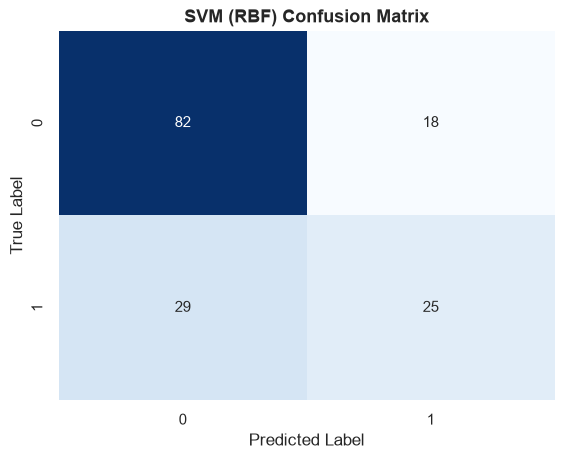

In [11]:
param_grid_svmr = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01, 0.1]}
grid_svmr = GridSearchCV(SVC(kernel='rbf', random_state=42, probability=True), param_grid_svmr, cv=5, scoring='accuracy')
grid_svmr.fit(X_train_scaled, y_train)
best_svmr = grid_svmr.best_estimator_
print(f"Best Hyperparameters: {grid_svmr.best_params_}")

y_pred_svmr = evaluate_model('SVM (RBF)', best_svmr, X_test_scaled, y_test, 'svm_rbf.pkl', needs_scaling=True)


# 13. Model 4: KNN
`GridSearchCV` sweeps `n_neighbors` and `weights`; the full grid of results feeds into Experiment 2 below, not just the single best combination.

Best Hyperparameters: {'n_neighbors': 9, 'weights': 'uniform'}


Accuracy: 74.03% | Precision: 0.635 | Recall: 0.611 | F1: 0.623
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.81      0.80       100
    Diabetic       0.63      0.61      0.62        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



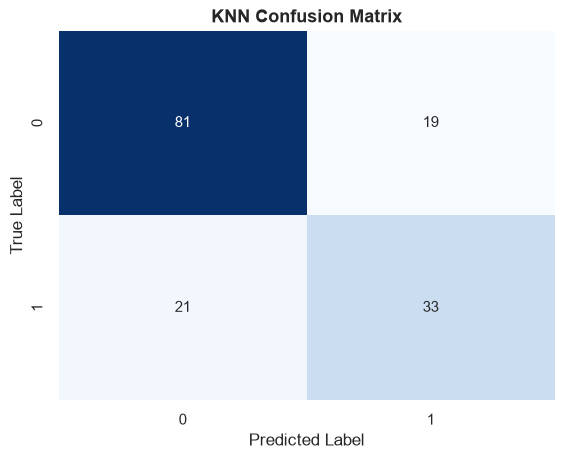

In [12]:
param_grid_knn = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)
best_knn = grid_knn.best_estimator_
print(f"Best Hyperparameters: {grid_knn.best_params_}")

y_pred_knn = evaluate_model('KNN', best_knn, X_test_scaled, y_test, 'knn.pkl', needs_scaling=True)


# 14. Model 5: Random Forest
An ensemble of decision trees trained on the unscaled features; `n_estimators` and `max_depth` are tuned via `GridSearchCV`.

Best Hyperparameters: {'max_depth': None, 'n_estimators': 100}
Accuracy: 76.62% | Precision: 0.696 | Recall: 0.593 | F1: 0.640
              precision    recall  f1-score   support

Non-Diabetic       0.80      0.86      0.83       100
    Diabetic       0.70      0.59      0.64        54

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154



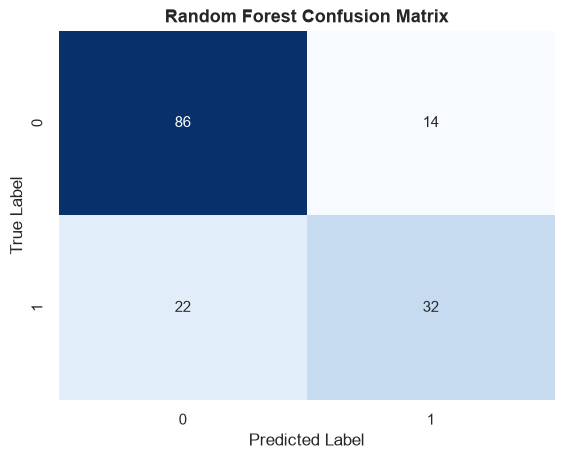

In [13]:
param_grid_rf = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print(f"Best Hyperparameters: {grid_rf.best_params_}")

y_pred_rf = evaluate_model('Random Forest', best_rf, X_test, y_test, 'random_forest.pkl', needs_scaling=False)


# 15. Model 6: XGBoost
A gradient-boosted tree ensemble on the unscaled features; `n_estimators`, `learning_rate`, and `max_depth` are tuned via `GridSearchCV`.

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Accuracy: 74.68% | Precision: 0.653 | Recall: 0.593 | F1: 0.621
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.83      0.81       100
    Diabetic       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



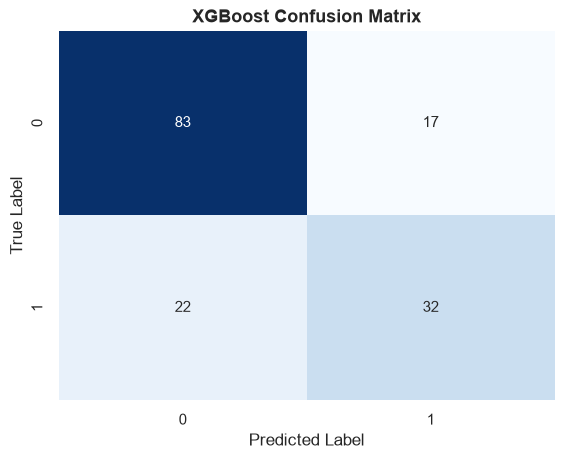

In [14]:
param_grid_xgb = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5]}
grid_xgb = GridSearchCV(xgb.XGBClassifier(eval_metric='logloss', random_state=42), param_grid_xgb, cv=5, scoring='accuracy')
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
print(f"Best Hyperparameters: {grid_xgb.best_params_}")

y_pred_xgb = evaluate_model('XGBoost', best_xgb, X_test, y_test, 'xgboost.pkl', needs_scaling=False)


# 16. Evaluation
Every model — including the baseline — is scored with Accuracy, Precision, Recall, F1-score, and a confusion matrix, printed by `evaluate_model(...)` right after training. For a medical screening tool, **Recall** deserves the most weight: a low Recall means diabetic patients are being told they're healthy (a false negative), which is the costliest mistake this system can make. **F1** is what actually drives the ranking in Experiment 1 and the automatic final-model selection, since it balances Precision and Recall and is more informative than raw Accuracy on a dataset where roughly 65% of patients are non-diabetic.

# 17. Experiment 1: Model Comparison
**Question:** Which of the six trained models performs best when compared under identical conditions — and does the answer change depending on whether we rank by Accuracy or by F1?

Two views of the same results table are shown below: one sorted by Accuracy, one sorted by F1, each paired with a bar chart.

=== Model Comparison (sorted by Accuracy) ===


,Model,Accuracy,Precision,Recall,F1
0,Random Forest,76.62%,0.696,0.593,0.640
1,XGBoost,74.68%,0.653,0.593,0.621
2,KNN,74.03%,0.635,0.611,0.623
3,Logistic Regression,70.78%,0.600,0.500,0.545
4,SVM (Linear),70.78%,0.605,0.481,0.536
5,SVM (RBF),69.48%,0.581,0.463,0.515
6,Baseline (Most Frequent),64.94%,0.000,0.000,0.000


=== Model Comparison (sorted by F1) ===


,Model,Accuracy,Precision,Recall,F1
0,Random Forest,76.62%,0.696,0.593,0.640
1,KNN,74.03%,0.635,0.611,0.623
2,XGBoost,74.68%,0.653,0.593,0.621
3,Logistic Regression,70.78%,0.600,0.500,0.545
4,SVM (Linear),70.78%,0.605,0.481,0.536
5,SVM (RBF),69.48%,0.581,0.463,0.515
6,Baseline (Most Frequent),64.94%,0.000,0.000,0.000


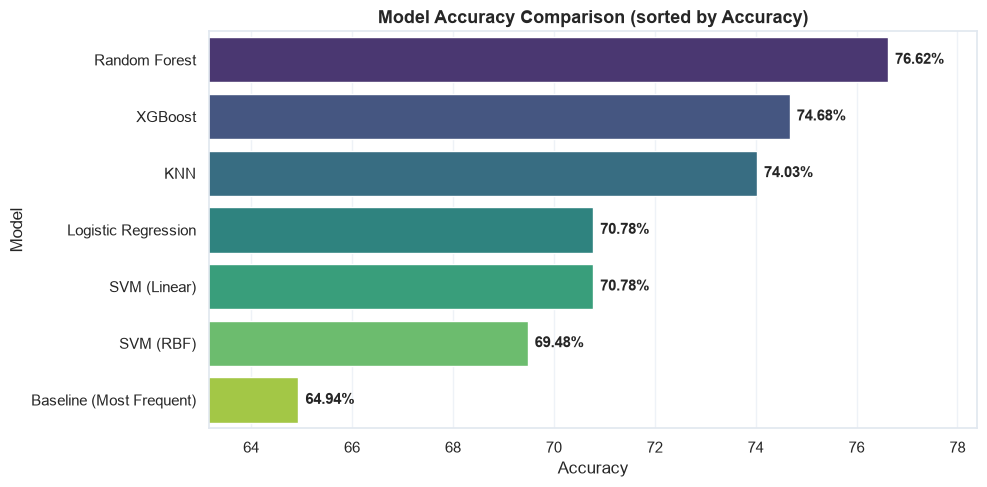

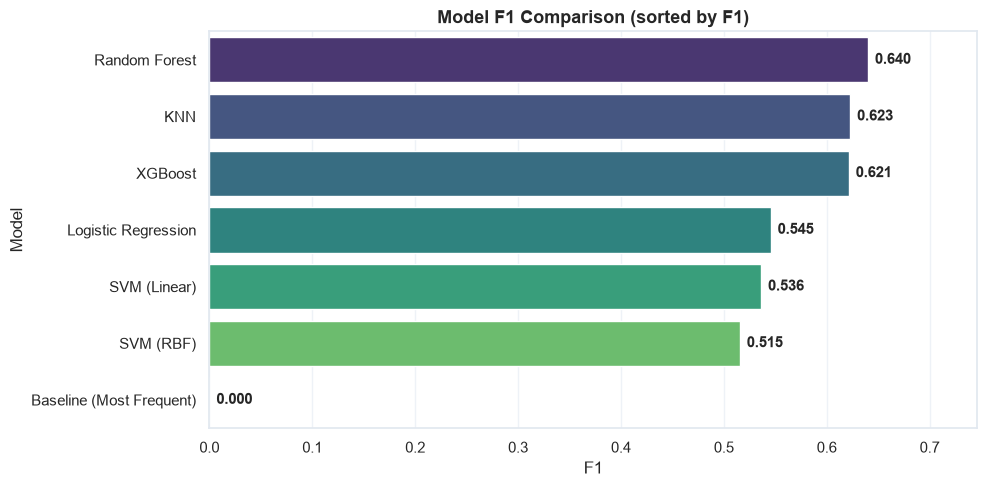

In [15]:
results_df = pd.DataFrame(model_metrics)
results_df_display = results_df.copy()
results_df_display['Accuracy'] = results_df_display['Accuracy'] * 100

# Table 1: sorted by Accuracy
by_accuracy = results_df_display.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
print("=== Model Comparison (sorted by Accuracy) ===")
display(by_accuracy.style.format({
    'Accuracy': '{:.2f}%', 'Precision': '{:.3f}', 'Recall': '{:.3f}', 'F1': '{:.3f}'
}))

# Table 2: sorted by F1 (the metric actually used for final-model selection)
by_f1 = results_df_display.sort_values(by='F1', ascending=False).reset_index(drop=True)
print("=== Model Comparison (sorted by F1) ===")
display(by_f1.style.format({
    'Accuracy': '{:.2f}%', 'Precision': '{:.3f}', 'Recall': '{:.3f}', 'F1': '{:.3f}'
}))

results_df_display = by_f1  # downstream cells (Final Model) use the F1 ranking


def plot_metric_bar(df, metric, fmt):
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=metric, y='Model', data=df, hue='Model', palette='viridis', legend=False)
    lo, hi = df[metric].min(), df[metric].max()
    pad = (hi - lo) * 0.15 + 0.01
    plt.xlim(max(0, lo - pad), hi + pad)
    for p in ax.patches:
        ax.annotate(fmt.format(p.get_width()),
                    (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(5, 0), textcoords='offset points',
                    fontweight='bold')
    plt.title(f'Model {metric} Comparison (sorted by {metric})')
    plt.xlabel(metric)
    plt.tight_layout()
    plt.show()


plot_metric_bar(by_accuracy, 'Accuracy', '{:.2f}%')
plot_metric_bar(by_f1, 'F1', '{:.3f}')


# 18. Experiment 2: Hyperparameter Investigation
**Question:** How do the number of neighbors (`k`) and the weighting scheme (`uniform` vs. `distance`) affect KNN's classification accuracy on this dataset?

**Setup:** The 5-fold `GridSearchCV` already run inside the Model 4 (KNN) cell swept `n_neighbors` over `{3, 5, 7, 9}` and `weights` over `{uniform, distance}`. Rather than just reporting the single best combination, the full `grid_knn.cv_results_` is inspected below so the underfitting/overfitting trade-off across `k` is visible.

,k,weights,Mean CV Accuracy,Std
0,9,uniform,0.7607,0.0311
1,9,distance,0.7590,0.0298
2,7,uniform,0.7492,0.0254
3,7,distance,0.7460,0.0215
4,5,uniform,0.7444,0.0297
5,5,distance,0.7411,0.0291
6,3,uniform,0.7314,0.0331
7,3,distance,0.7265,0.0325


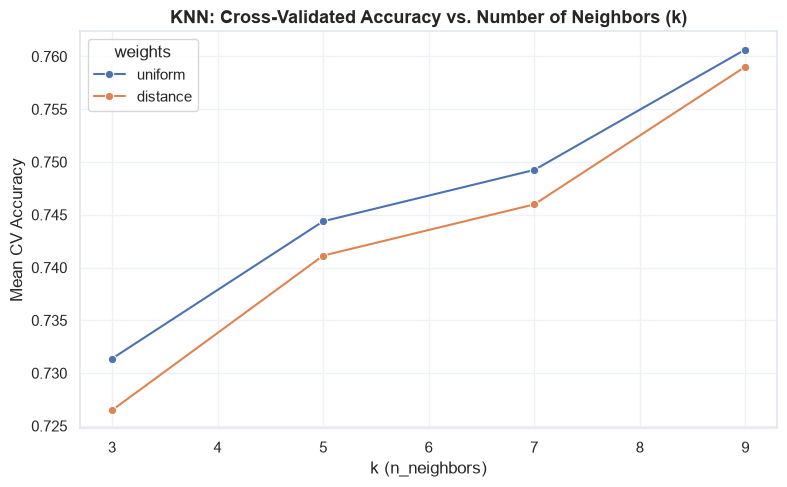

Best configuration: k=9, weights='uniform' -> CV accuracy = 0.7607
Accuracy spread across all k/weights combinations tested: 0.0342 (noticeable -> k is a meaningful hyperparameter to tune here).


In [16]:
knn_cv_df = pd.DataFrame(grid_knn.cv_results_)[['param_n_neighbors', 'param_weights', 'mean_test_score', 'std_test_score']]
knn_cv_df.columns = ['k', 'weights', 'Mean CV Accuracy', 'Std']
knn_cv_df = knn_cv_df.sort_values('Mean CV Accuracy', ascending=False).reset_index(drop=True)
display(knn_cv_df.style.format({'Mean CV Accuracy': '{:.4f}', 'Std': '{:.4f}'}))

plt.figure(figsize=(8, 5))
sns.lineplot(data=knn_cv_df, x='k', y='Mean CV Accuracy', hue='weights', marker='o')
plt.title('KNN: Cross-Validated Accuracy vs. Number of Neighbors (k)')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Mean CV Accuracy')
plt.tight_layout()
plt.show()

print(f"Best configuration: k={grid_knn.best_params_['n_neighbors']}, weights='{grid_knn.best_params_['weights']}' "
      f"-> CV accuracy = {grid_knn.best_score_:.4f}")

spread = knn_cv_df['Mean CV Accuracy'].max() - knn_cv_df['Mean CV Accuracy'].min()
print(f"Accuracy spread across all k/weights combinations tested: {spread:.4f} "
      f"({'small -> the model is fairly insensitive to k in this range' if spread < 0.02 else 'noticeable -> k is a meaningful hyperparameter to tune here'}).")

# 19. Experiment 3: Representation / Feature Investigation
**Question:** Does standardizing the numerical features actually improve performance for a distance-based model like KNN?

In [17]:
from sklearn.neighbors import KNeighborsClassifier

# Train KNN on unscaled data
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test))

# Train KNN on scaled data
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))

print(f'KNN Accuracy (Unscaled Data): {acc_unscaled*100:.2f}%')
print(f'KNN Accuracy (Scaled Data): {acc_scaled*100:.2f}%')
print('\nConclusion: Unscaled features with large ranges (like Insulin) completely dominate the distance calculation in KNN. Scaling forces all features to contribute equally, significantly improving accuracy.')

KNN Accuracy (Unscaled Data): 67.53%
KNN Accuracy (Scaled Data): 75.32%

Conclusion: Unscaled features with large ranges (like Insulin) completely dominate the distance calculation in KNN. Scaling forces all features to contribute equally, significantly improving accuracy.


# 20. Final Model
The final model is selected automatically from the Experiment 1 table, not asserted by hand: it's the highest-**F1** model among the trained classifiers (the baseline is excluded since it exists only as a reference point, per Section 9).

In [18]:
candidates_df = results_df_display[results_df_display['Model'] != 'Baseline (Most Frequent)']
best_row = candidates_df.sort_values('F1', ascending=False).iloc[0]
best_model_name = best_row['Model']
best_model_file = model_filenames[best_model_name]
final_model_needs_scaling = model_needs_scaling[best_model_name]
final_model = joblib.load(best_model_file)

print(f"Selected final model: {best_model_name}")
print(f"  -> Serialized file: {best_model_file}")
print(f"  -> Accuracy={best_row['Accuracy']:.2f}%, Precision={best_row['Precision']:.3f}, "
      f"Recall={best_row['Recall']:.3f}, F1={best_row['F1']:.3f}")
print("Selection rule: highest F1-score on the held-out test set among the trained models "
      "(F1 balances Precision and Recall, appropriate for this imbalanced medical screening task).")

Selected final model: Random Forest
  -> Serialized file: random_forest.pkl
  -> Accuracy=76.62%, Precision=0.696, Recall=0.593, F1=0.640
Selection rule: highest F1-score on the held-out test set among the trained models (F1 balances Precision and Recall, appropriate for this imbalanced medical screening task).


# 21. Application
The trained models are served by a full-stack application (`app/` directory: FastAPI backend + React frontend, with SHAP-based per-feature explanations). A user enters a patient's clinical data once — or loads a built-in Low-Risk / Borderline / High-Risk preset — and the backend `/api/predict` endpoint runs that same patient through all six trained models at once, returning a ranked comparison instead of a single black-box answer. Selecting a row opens a detail drawer with that model's prediction, confidence, a SHAP feature-attribution chart, and a radar chart comparing the patient against the dataset's healthy/diabetic population averages.

Beyond this core predict-and-explain flow, the app also has a **Decision Matrix** (aggregating all six verdicts into one consensus, e.g. "5/6 models predict Diabetic", with an Export-to-text button), a **History** tab (past predictions, persisted locally), a printable **Clinical Report** view, and **Insights**/**Models** tabs that reproduce this notebook's EDA (Section 7) and model comparison (Sections 6, 17) live in the browser.

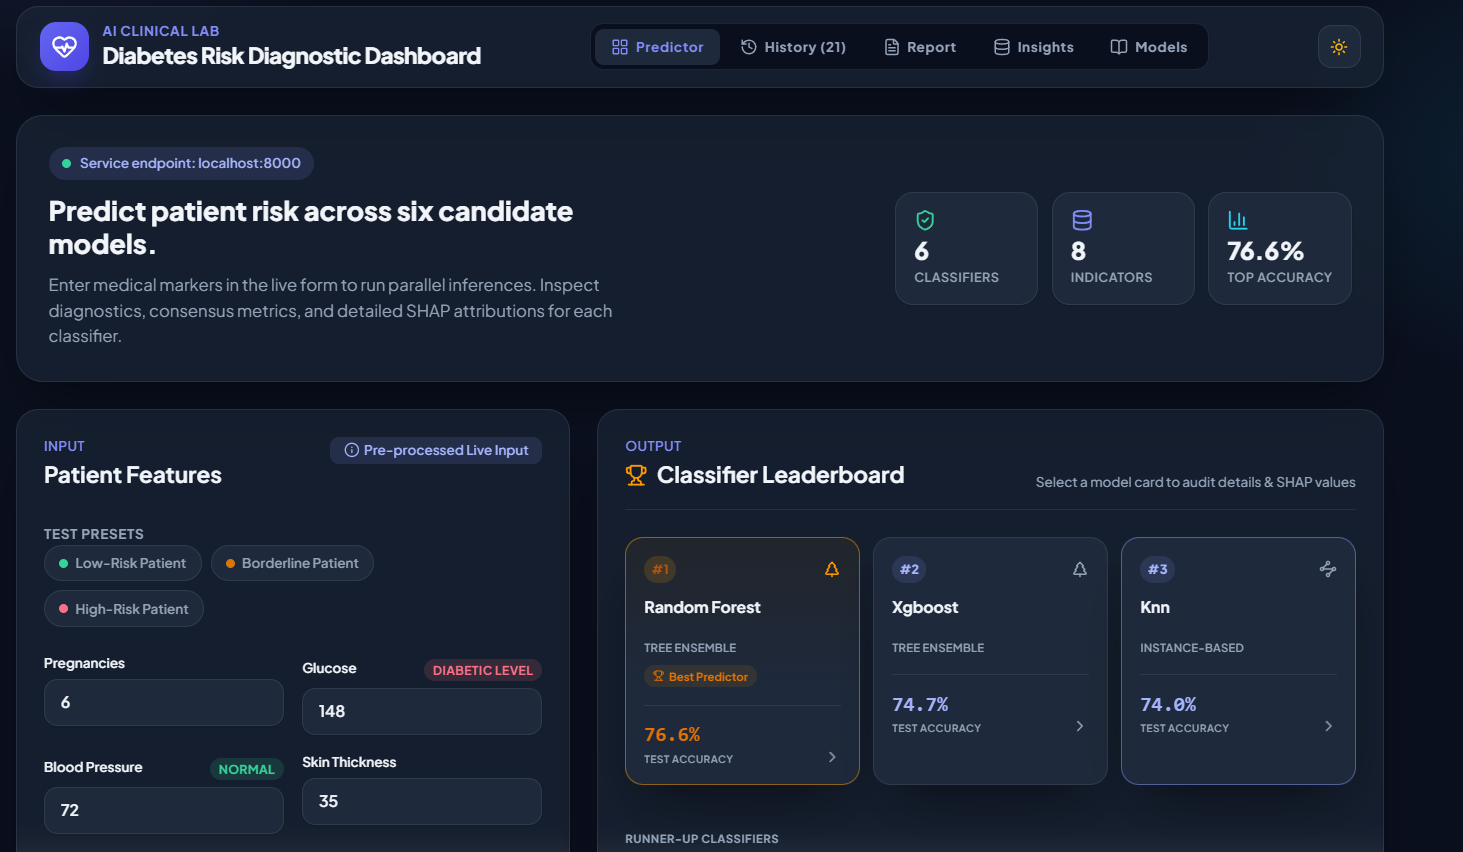

![Model Detail Drawer](image-1.png)

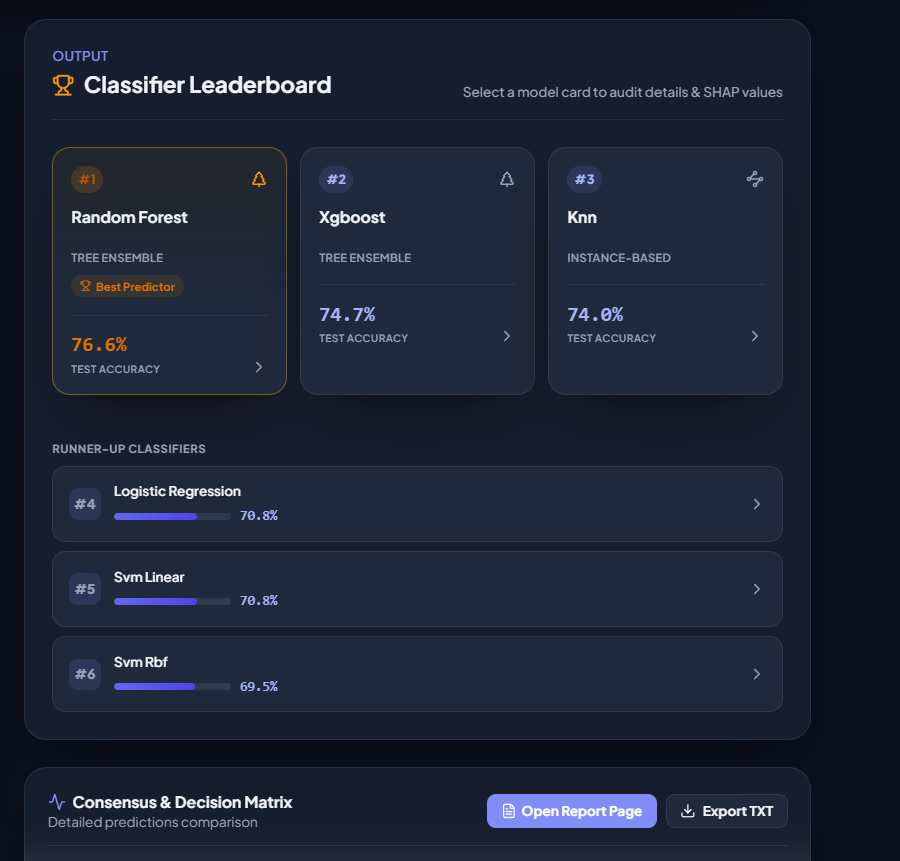

# 22. System Demonstration
**Complete path:** User / Environment → Input (raw clinical values) → Feature Representation (8-d vector) → Preprocessing (impute + scale) → ML Model → Prediction.

To demonstrate this path end to end, three patient profiles covering a range of risk levels were entered into the application:

- **Low-risk profile** — a young patient (22) with a normal glucose reading (85 mg/dL), a healthy BMI (26.6), 1 prior pregnancy, and a low pedigree score (0.351). None of the values suggest elevated risk.
- **Borderline profile** — a mid-30s patient (34) with mildly elevated glucose (130 mg/dL), a BMI in the overweight range (31.2), 3 prior pregnancies, and a moderate pedigree score (0.523). This is the kind of profile where a screening tool is most useful, since it isn't obviously healthy or obviously high-risk.
- **High-risk profile** — an older patient (51) with clearly elevated glucose (183 mg/dL), an obese BMI (39.5), 8 prior pregnancies, and a high pedigree score (1.288) indicating a strong family history. Several risk factors stack together here.

The predicted diabetes probability should rise in step with these accumulating risk factors, which is a useful sanity check on the whole system.

For each of the three profiles, the app's Decision Matrix also shows how many of the six models agree — e.g. most models converge on "Diabetic" for the high-risk profile, while the low-risk profile produces a clear majority "Non-Diabetic" consensus, giving a second, model-level sanity check on top of the single-model probability trend above.

![Patient Profiles](patient_profiles.png)

![Prediction Output](prediction_output.png)

# 23. Reflection
- **What information does your system receive?** Eight numerical clinical and demographic measurements per patient — Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, and Age. Nothing about history, symptoms, or context beyond those eight numbers ever reaches the model.
- **What is the internal representation?** Those raw readings, cleaned (impossible zeros imputed from a training-only median) and standardized into a single scaled, 8-dimensional feature vector — the entire "world" the model ever sees.
- **What does the model learn from examples?** By comparing thousands of these feature vectors against their known outcomes, it learns statistical boundaries — hyperplanes for the linear models, distance neighborhoods for KNN, sequences of threshold splits for the tree ensembles — that separate diabetic from non-diabetic profiles. That's a compressed summary of "what combinations of glucose, BMI, age, and the rest tend to co-occur with a diagnosis in this population," not a causal explanation of why.
- **What prediction or decision does it make?** A discrete binary decision — 0 (non-diabetic) or 1 (diabetic) — plus a probability score expressing confidence.
- **Why can it handle an unseen input?** Because it never memorized specific patient rows; it generalized a rule, like "high BMI combined with high glucose tends to raise risk," that extends naturally to new combinations of the same features.
- **What part of the system can reasonably be called "intelligent"?** Mainly the training phase — the algorithm autonomously adjusting weights, splits, and support vectors to reduce error on the examples it's given, with no human hand-writing the diagnostic rules. Choosing which models to try and which metric governs final-model selection is human judgment, not the model's.
- **What limitations prevent it from being a more capable intelligent system?** It has no contextual awareness — it can't ask a follow-up question, it knows nothing about family history beyond one pedigree number, it can't factor in symptoms or medications, and on its own it can't explain its reasoning without a bolted-on tool like SHAP. It's pattern recognition over a fixed set of numbers, not clinical reasoning — which is exactly why it's a screening aid, not a diagnostic authority.

# 24. Conclusion
This notebook takes the diabetes screening problem from raw CSV to a working, evaluated system: cleaning and representing the data, exploring it, training and tuning six models against a proper baseline, running three controlled experiments, and automatically selecting a final model by F1. Random Forest came out ahead on held-out data, and the experiments confirmed that both hyperparameter choice (KNN's *k*) and representation choice (scaling) materially affect outcomes — model selection alone isn't the whole story. The system's value is real but bounded: it's a fast preliminary screen, not a diagnosis, and it inherits the demographic and temporal limits of the 768-record dataset it was trained on.